# Diabetic Retinopathy — Dual-Track Ensemble Notebook

**Tracks implemented in this notebook:**
| Track | Architecture | Pretrained | Output |
|-------|-------------|-----------|--------|
| **Custom** | `CustomCNN × 2` + `VGG16-BN` (from scratch) | ✗ | `output_custom.csv` |
| **Fine-tune** | `EfficientNet-B2` + `DenseNet-121` + `TinyViT-21M` | ✓ | `output_ft.csv` |

**Metric:** AUC (area under the ROC curve)  
**Submission:** `results/outputs/c{AUC_custom}_ft{AUC_ft}_{date}.zip`

---
## Pipeline overview
```
data/train.csv + images/
     │
     ▼
RetinopathyDataset  ──  right-eye mirror · CLAHE · intensity-scaled augmentations
WeightedRandomSampler  ──  balance DR vs No-DR
     │
     ├── [CustomConfig]   EnsembleModel(['CustomCNN','CustomCNN','vgg16_bn'], pretrained=False)
     │                         └── Trainer (BCEWithLogitsLoss on member logits)
     │
     └── [FineTuneConfig] EnsembleModel(['efficientnet_b2','densenet121','tiny_vit_21m_...'], pretrained=True)
                               └── Trainer (BCELoss on averaged probabilities)
                                         ▼
                               results/outputs/{custom,ft}.csv
                               results/c{AUC}_ft{AUC}_{date}.zip
```

---
## 0 · Imports & reproducibility

In [ ]:
!pip install -q numpy pandas scipy seaborn timm colorama
!pip install -q torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2

In [ ]:
%matplotlib inline
from __future__ import print_function, division

import os, sys, random, csv, warnings, shutil
from datetime import datetime
from zipfile import ZipFile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn import metrics

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# ── Define proyect routes ───────────────────────────────────────────────────
ROOT_DIR = Path("/kaggle/input/datasets/santiagoprietonuez/cv-proy05")
WORKING_DIR = Path("/kaggle/working/cv-directory")

for folder in ['src', 'utils']:
    orig_path = ROOT_DIR / folder
    dest_path = WORKING_DIR / folder
    
    if os.path.exists(dest_path):
        shutil.rmtree(dest_path) # Clean if we have a previous execution
    
    shutil.copytree(orig_path, dest_path)
    print(f"Copied {folder} in {WORKING_DIR}")


os.chdir(WORKING_DIR)
print("Actual directory content: ", os.listdir())

Rewrite the Config file for Kaggle execution

In [ ]:
%%writefile utils/config.py
import torch
from pathlib import Path
from torch.cuda import is_available
from colorama import Fore

class Config:
    # ---- Hardware ----
    device = "cuda" if is_available() else "cpu"

    # ---- Hardware & paths ----
    data_dir = Path("/kaggle/input/datasets/santiagoprietonuez/data-cv/data")

    # Writing directory
    base_dir = Path("/kaggle/working/cv-directory")

    # Input kaggle route
    train_csv  = data_dir / "train.csv"
    val_csv    = data_dir / "val.csv"
    test_csv   = data_dir / "test.csv"
    images_dir = data_dir / "images"

    # Rutas de SALIDA (Working)
    checkpoint_dir = base_dir / "results" / "checkpoints"
    output_dir     = base_dir / "results" / "outputs"
    results_dir    = base_dir / "results"

    
    # ── Multi-scale ensemble resolution (one scale per member) ───────────────
    # Model A: 224×224 — global context  (low-res, broad features)
    # Model B: 384×384 — mid-scale       (balanced detail/context)
    # Model C: 512×512 — fine lesions    (full resolution, small structures)
    ensemble_scales = [224, 384, 512]

    # ── Data parameters ───────────────────────────────────────────────────────
    # Use 512 as the canonical input size (largest ensemble scale).
    # rescale_size must be slightly larger than img_height so that
    # RandomCrop always has room to crop without padding artifacts.
    img_height   = 512
    img_width    = 512
    num_channels = 3
    rescale_size = 580          # rescale shortest side before RandomCrop(512)

    # ── Training hyperparameters ──────────────────────────────────────────────
    num_clasess     = 1         # binary → single logit, BCEWithLogitsLoss
    unfreeze_layers = 2         # how many layer groups to unfreeze in BaseModel
    batch_size      = 16        # reduced for 512×512 inputs
    num_epochs      = 50
    learning_rate   = 3e-4     # AdamW starting LR
    weight_decay    = 1e-4
    lr_patience     = 3         # ReduceLROnPlateau patience (epochs)
    lr_factor       = 0.3       # LR multiplier on plateau
    early_stopping  = 10        # early-stopping patience (val AUC epochs)
    seed            = 42

    # ── TTA (Test-Time Augmentation) ──────────────────────────────────────────
    # Each test image is forward-passed num_tta times with random flips/rotations.
    # The final score is the mean over all passes.  Set to 1 to disable TTA.
    num_tta = 10

    # ── Focal Loss hyperparameters ────────────────────────────────────────────
    # alpha: balances positive/negative class weight in the focal formula.
    # gamma: focusing parameter — higher values down-weight easy examples more.
    focal_alpha = 0.25
    focal_gamma = 2.0

    # ── Augmentation flags & intensity ────────────────────────────────────────
    aug_rigid      = True       # rotation, h/v flip
    aug_regularize = True       # Gaussian noise
    aug_clahe      = True       # dual CLAHE (green + red channels)
    aug_ben_graham = True       # alias kept for backward compatibility
    aug_intensity  = 0.7        # global magnitude scalar [0.0, 1.0]

    # ── CLAHE parameters ──────────────────────────────────────────────────────
    clahe_clip = 2.0            # clipLimit for cv2.createCLAHE
    clahe_grid = (4, 4)         # tileGridSize for cv2.createCLAHE

    # ── ImageNet normalization (used for pretrained backbones) ────────────────
    pixel_mean = [0.485, 0.456, 0.406]
    pixel_std  = [0.229, 0.224, 0.225]


# =============================================================================
# CustomConfig  —  train everything from scratch
# =============================================================================
class CustomConfig(Config):
    pretrained      = False
    aug_intensity   = 0.9       # aggressive augmentation for random-init models
    unfreeze_layers = -1        # -1 → train all parameters (no freezing)
    num_epochs      = 60
    learning_rate   = 5e-4     # higher LR for random initialisation
    weight_decay    = 5e-4
    lr_patience     = 5
    early_stopping  = 15
    batch_size      = 16

    checkpoint_dir  = Config.base_dir / "results" / "checkpoints" / "custom"
    checkpoint_name = "multiRes_custom_ensemble.pth"
    output_path     = Config.output_dir / "output_custom.csv"


# =============================================================================
# FineTuneConfig  —  ImageNet pretrained + partial fine-tuning
# =============================================================================
class FineTuneConfig(Config):
    pretrained      = True
    aug_intensity   = 0.6
    unfreeze_layers = 3         # unfreeze the last 3 layer groups
    num_epochs      = 50
    learning_rate   = 3e-4
    weight_decay    = 1e-4
    lr_patience     = 3
    early_stopping  = 10
    batch_size      = 16        # 512×512 needs smaller batches than 224×224

    checkpoint_dir  = Config.base_dir / "results" / "checkpoints" / "finetune"
    checkpoint_name = "multi_resolution_ensemble.pth"
    output_path     = Config.output_dir / "output_ft.csv"

In [4]:
%matplotlib inline
from __future__ import print_function, division

import os, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# ── Project imports ──────────────────────────────────────────────────────────
from utils.config import (
    Config as cfg, 
    CustomConfig as custom_cfg,
    FineTuneConfig as ft_cfg,
)
from utils.data_processing import get_dataloader, apply_clahe_green

from src.model import EnsembleModel
from utils.trainer import Trainer

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = cfg.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'Device  : {cfg.device}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed    : {SEED}')

Device  : cuda
PyTorch : 2.10.0+cu128
Seed    : 42


---
## 1 · Exploratory Data Analysis (EDA)

In [5]:
# ── Load split CSVs ──────────────────────────────────────────────────────────
train_df = pd.read_csv(cfg.train_csv, dtype={'id': str, 'eye': int, 'label': int})
val_df   = pd.read_csv(cfg.val_csv,   dtype={'id': str, 'eye': int, 'label': int})
test_df  = pd.read_csv(cfg.test_csv,  dtype={'id': str, 'eye': int, 'label': int})

print(f'Train : {len(train_df):>5,} samples')
print(f'Val   : {len(val_df):>5,} samples')
print(f'Test  : {len(test_df):>5,} samples')
train_df.head()

Train : 2,000 samples
Val   :   500 samples
Test  : 1,000 samples


,id,eye,label
0,00000,0,0
1,00001,1,0
2,00002,1,2
3,00003,1,0
4,00004,0,0


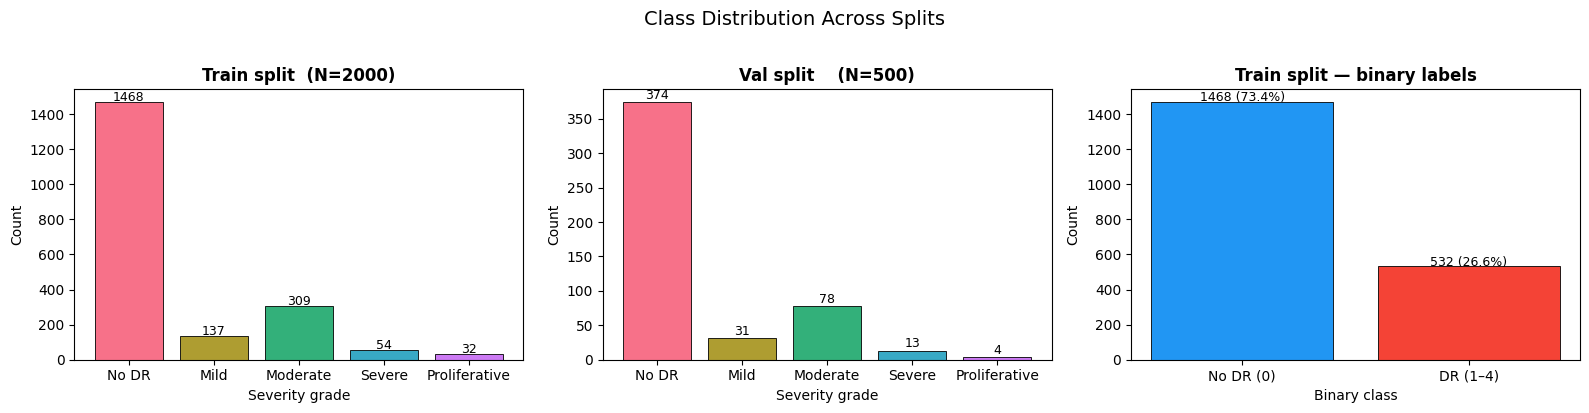

Class imbalance ratio  No-DR : DR = 0.73 : 0.27
Implied pos_weight            = 2.759


In [6]:
# ─── Class distribution ───────────────────────────────────────────────────────
severity_labels = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}
binary_labels   = {0: 'No DR (0)', 1: 'DR (1–4)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette   = sns.color_palette('husl', 5)

for ax, (df, title) in zip(axes, [
    (train_df, 'Train split  (N=2000)'),
    (val_df,   'Val split    (N=500)'),
]):
    counts = df['label'].value_counts().sort_index()
    ax.bar([severity_labels[i] for i in counts.index], counts.values,
           color=palette[:len(counts)], edgecolor='k', linewidth=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

# Binary view
ax = axes[2]
binary_counts = (train_df['label'] > 0).value_counts().sort_index()
ax.bar([binary_labels[i] for i in binary_counts.index], binary_counts.values,
       color=['#2196F3', '#F44336'], edgecolor='k', linewidth=0.6)
ax.set_title('Train split — binary labels', fontsize=12, fontweight='bold')
ax.set_xlabel('Binary class')
ax.set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    ax.text(i, v + 5, f'{v} ({100*v/len(train_df):.1f}%)', ha='center', fontsize=9)

plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

pos_frac = (train_df['label'] > 0).mean()
print(f'Class imbalance ratio  No-DR : DR = {1-pos_frac:.2f} : {pos_frac:.2f}')
print(f'Implied pos_weight            = {(1-pos_frac)/pos_frac:.3f}')

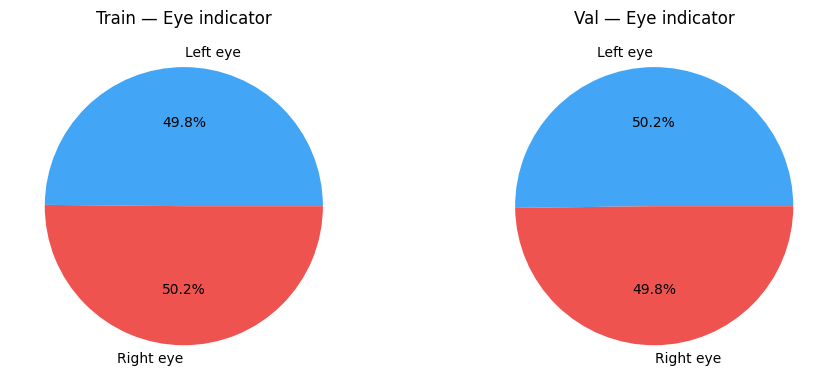

In [7]:
# ─── Eye indicator distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (df, title) in zip(axes, [
    (train_df, 'Train'),
    (val_df,   'Val'),
]):
    counts = df['eye'].value_counts().sort_index()
    ax.pie(counts.values, labels=['Left eye', 'Right eye'],
           autopct='%1.1f%%', colors=['#42A5F5', '#EF5350'])
    ax.set_title(f'{title} — Eye indicator')

plt.tight_layout()
plt.show()

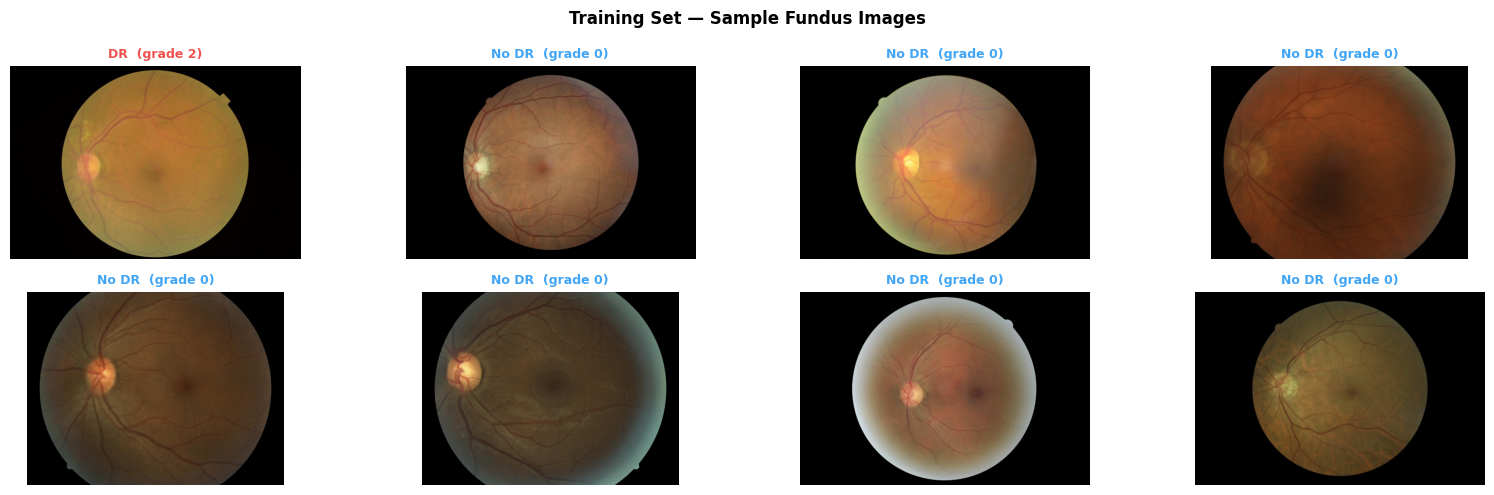

In [8]:
# ── Visualise sample fundus images ───────────────────────────────────────────
import skimage.io as skio
import skimage.util as skutil

IMG_DIR = cfg.images_dir

def show_samples(df, title, n=8):
    """Show n random fundus images from a DataFrame split."""
    sample = df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(16, 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        path = os.path.join(IMG_DIR, row['id'] + '.jpg')
        if not os.path.exists(path):
            axes[i].text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                         transform=axes[i].transAxes, fontsize=9, color='grey')
            axes[i].set_xticks([]); axes[i].set_yticks([])
            continue
        img = skio.imread(path)
        if row['eye'] == 1:
            img = img[:, ::-1, :]
        axes[i].imshow(img)
        label_str = 'DR' if row['label'] > 0 else 'No DR'
        color     = '#EF5350' if row['label'] > 0 else '#42A5F5'
        axes[i].set_title(f'{label_str}  (grade {row["label"]})',
                          color=color, fontsize=9, fontweight='bold')
        axes[i].axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_df, 'Training Set — Sample Fundus Images', n=8)

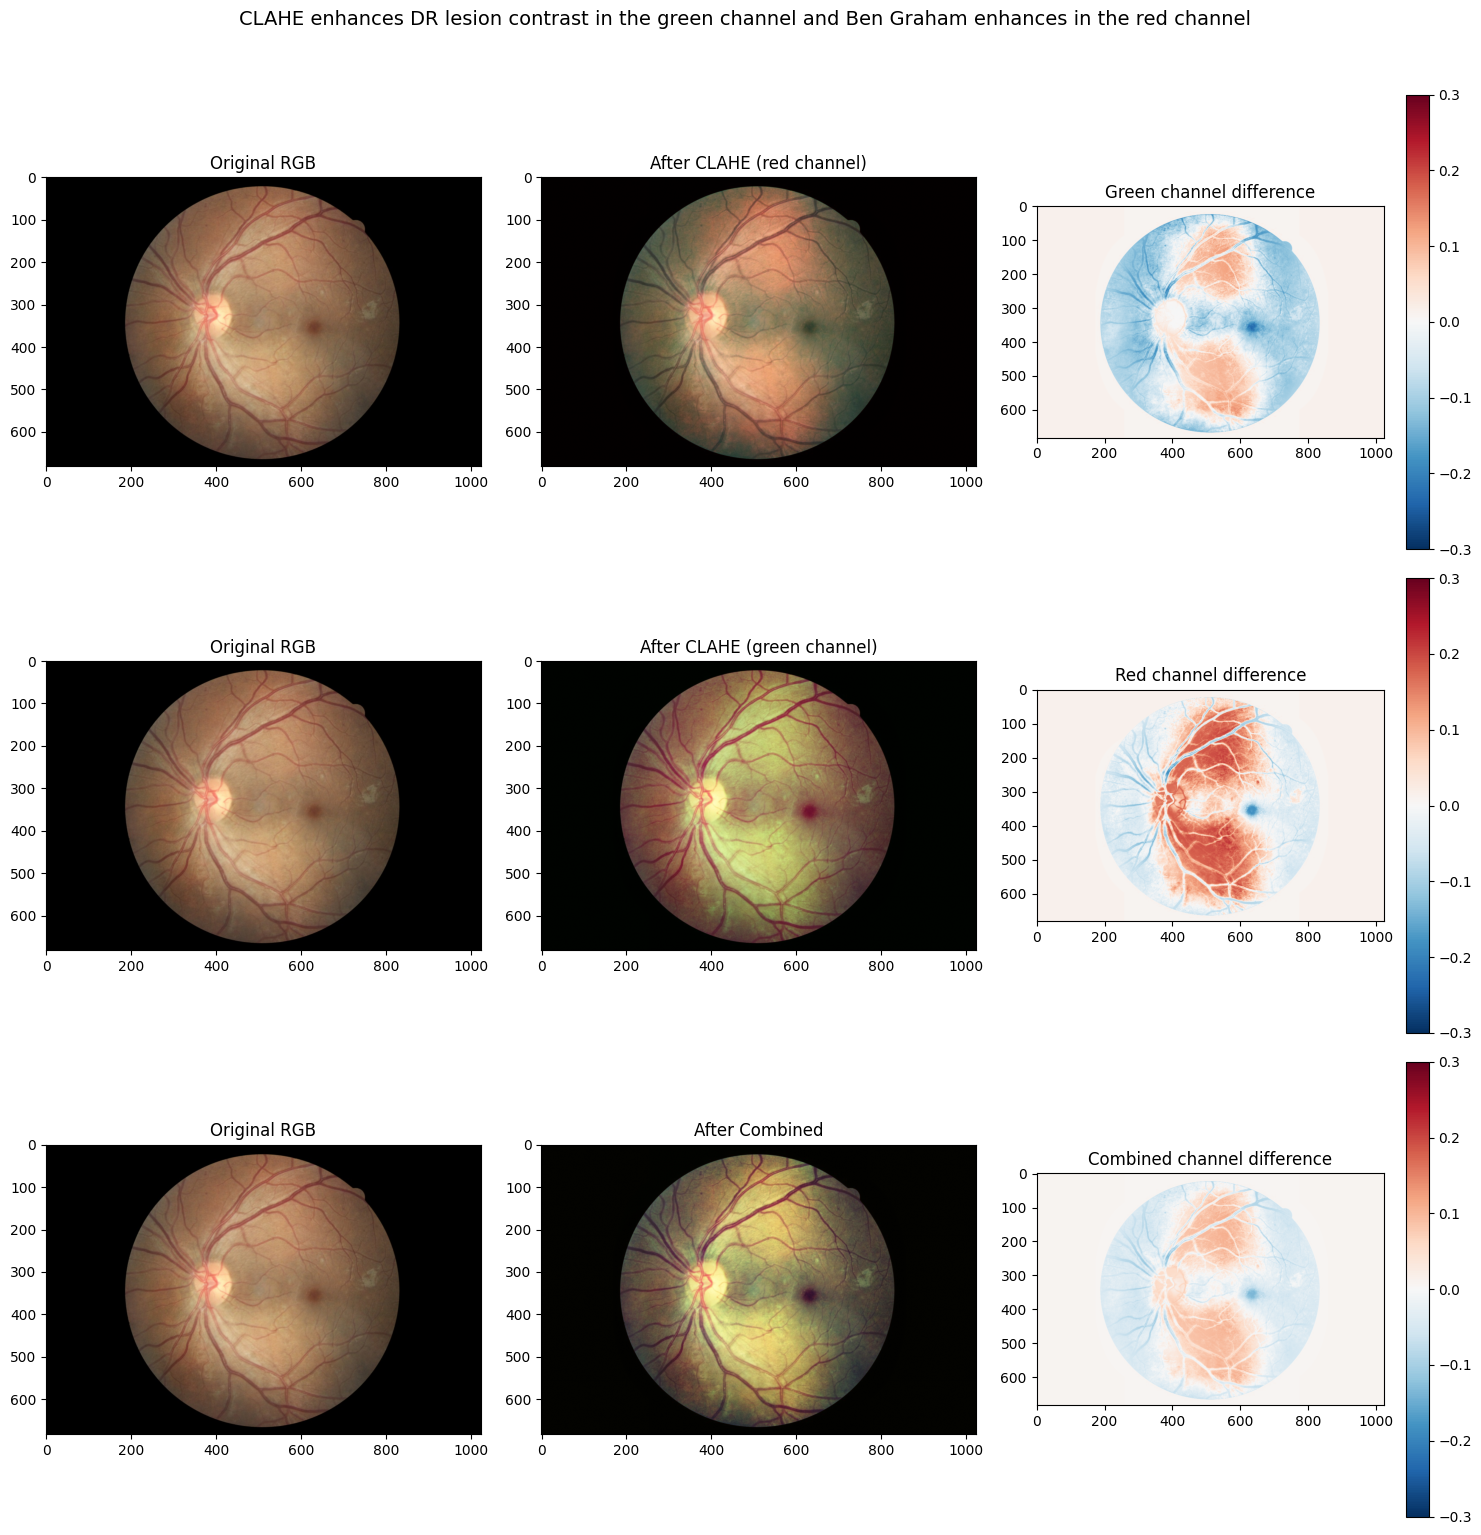

In [9]:
# ─── CLAHE and Ben Graham effect visualisation ───────────────────────────────────────────────
from utils.data_processing import apply_clahe_green, apply_clahe_red

row = train_df[train_df['label'] > 0].sample(1, random_state=1).iloc[0]
img = skutil.img_as_float(skio.imread(os.path.join(cfg.images_dir, row['id'] + '.jpg')))
img_clahe = apply_clahe_green(img)
img_clahe_red = apply_clahe_red(img)
img_combined = apply_clahe_red(img_clahe)

title = ["CLAHE (red channel)", "CLAHE (green channel)", "Combined"]
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, img_enhanced in enumerate([img_clahe_red, img_clahe, img_combined]):
    axes[i,0].imshow(img)
    axes[i,0].set_title('Original RGB')
    axes[i,1].imshow(img_enhanced)
    axes[i,1].set_title(f'After {title[i]}')
    # Difference map on channel
    if title[i] != "Combined":
        diff = img_enhanced[:,:,i].astype(float) - img[:,:,i].astype(float)
    else: # combined 
        diff = np.mean(img_enhanced - img, axis=2)
    im = axes[i,2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[i,2].set_title(f'{["Green", "Red", "Combined"][i]} channel difference')
    plt.colorbar(im, ax=axes[i,2])
plt.suptitle('CLAHE enhances DR lesion contrast in the green channel and Ben Graham enhances in the red channel',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2 · Dataloaders

In [10]:
# Set max_size=200 for a quick dev run; 0 = full dataset
MAX_SIZE = 0

train_dataset, train_loader = get_dataloader(
    cfg.train_csv, is_train=True,  batch_size=cfg.batch_size, max_size=MAX_SIZE)

val_dataset, val_loader = get_dataloader(
    cfg.val_csv,   is_train=False, batch_size=cfg.batch_size * 2)

_, test_loader = get_dataloader(
    cfg.test_csv,  is_train=False, batch_size=cfg.batch_size * 2)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Verify batch shapes
batch = next(iter(train_loader))
print(f"\nBatch image shape : {batch['image'].shape}")
print(f"Batch label shape : {batch['label'].shape}")
print(f"Label distribution: {batch['label'].float().mean():.2f} (expect ≈0.5 with sampler)")

[DataLoader] train.csv | No-DR: 1,468 | DR: 532 | WeightedSampler ratio ≈ 1:2.76
Train batches : 125
Val   batches : 16
Test  batches : 32

Batch image shape : torch.Size([16, 3, 512, 512])
Batch label shape : torch.Size([16])
Label distribution: 0.62 (expect ≈0.5 with sampler)


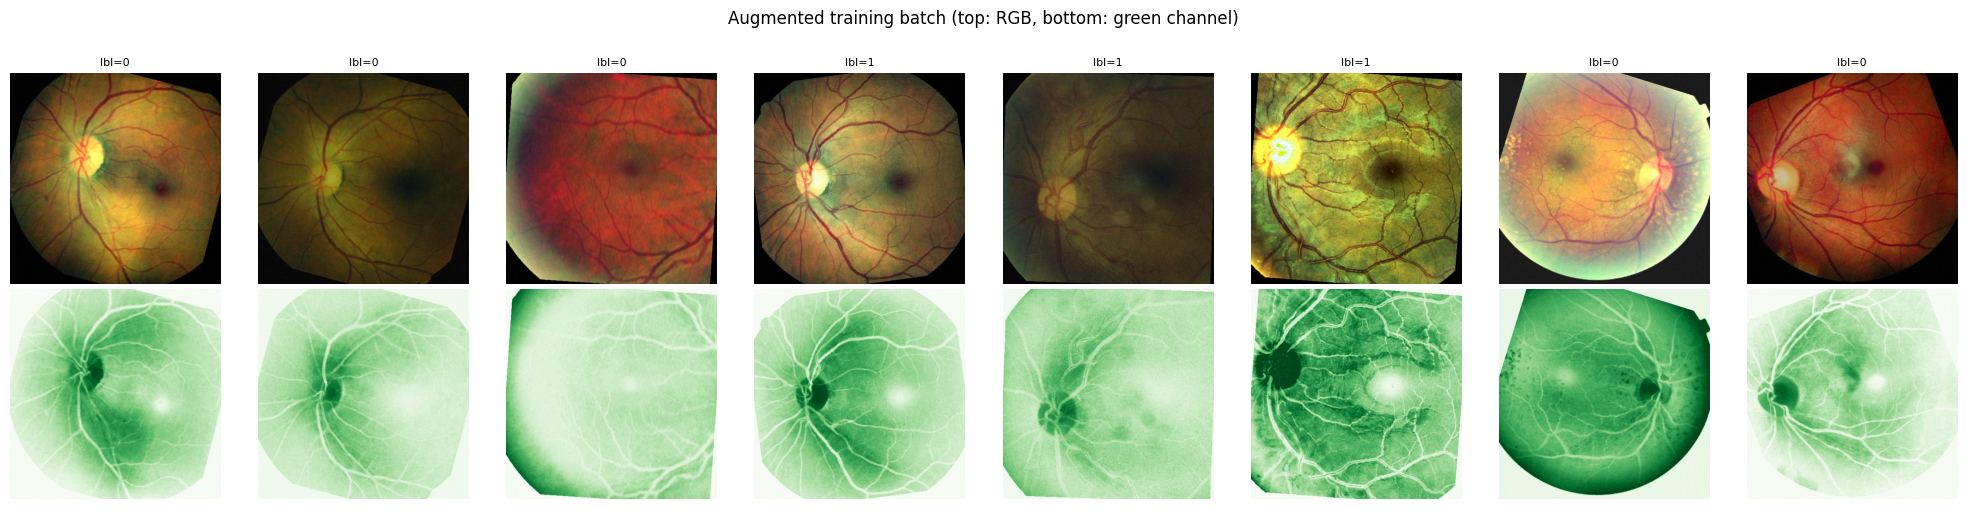

In [11]:
# ─── Augmentation visualisation ──────────────────────────────────────────────
# Compare the same image before / after the augmentation pipeline
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
imgs = batch['image'][:8]   # first 8 images from the augmented batch

mean = np.array(cfg.pixel_mean)[:, None, None]
std  = np.array(cfg.pixel_std)[:, None, None]

for i in range(8):
    # De-normalise for display
    img_np = (imgs[i].numpy() * std + mean).transpose(1, 2, 0)
    img_np = np.clip(img_np, 0, 1)
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"lbl={batch['label'][i].item()}", fontsize=8)
    axes[0, i].axis('off')
    # Green channel only
    axes[1, i].imshow(img_np[:, :, 1], cmap='Greens')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=9)
axes[1, 0].set_ylabel('Green ch.', fontsize=9)
plt.suptitle('Augmented training batch (top: RGB, bottom: green channel)', y=1.01)
plt.tight_layout()
plt.show()

## 3.0 Fine-tunning Model instantiation

In [12]:
# ── Ensemble ─────────────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

# one model per scale, 3 scales → 6 models (3 EfficientNet-B2 + 3 DenseNet-121)
backbones = list(["efficientnet_b2","efficientnet_b2","efficientnet_b2",
                      "densenet121","densenet121","densenet121",
                     ])

# load the checkpoint if it exists, otherwise create a new ensemble
already_trained = False
pth_path = ft_cfg.checkpoint_dir / ft_cfg.checkpoint_name
if os.path.exists(pth_path):
    print(f"Loading ensemble from checkpoint: {cfg.checkpoint_dir / ft_cfg.checkpoint_name}")
    already_trained = True

ensemble = EnsembleModel(
    backbone_names = backbones,
    unfreeze_n=ft_cfg.unfreeze_layers,
    pretrained=True,
    pth_path=pth_path if already_trained else None
)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 3, cfg.img_height, cfg.img_height)
    out   = ensemble(dummy)
    assert out.shape == (2, 1), f'Expected (2,1), got {out.shape}'
    print(f'\n✓ Forward pass OK  output shape: {out.shape}')
    print(f'  Sample probabilities: {out.squeeze().tolist()}')

Loading ensemble from checkpoint: /home/pawn/Desktop/vision/AutomaticDiagnosisForDiabeticRetinopathy/results/checkpoints/multi_resolution_ensemble.pth
efficientnet_b2 ENTRA EN PRETRAINED
[BaseModel] Total groups: 10.  Unfreezing last 3.
[BaseModel] efficientnet_b2 | total=7,702,403  trainable=3,235,661
efficientnet_b2 ENTRA EN PRETRAINED
[BaseModel] Total groups: 10.  Unfreezing last 3.
[BaseModel] efficientnet_b2 | total=7,702,403  trainable=3,235,661
efficientnet_b2 ENTRA EN PRETRAINED
[BaseModel] Total groups: 10.  Unfreezing last 3.
[BaseModel] efficientnet_b2 | total=7,702,403  trainable=3,235,661
densenet121 ENTRA EN PRETRAINED
[BaseModel] Total groups: 6.  Unfreezing last 3.
[BaseModel] densenet121 | total=6,954,881  trainable=4,996,865
densenet121 ENTRA EN PRETRAINED
[BaseModel] Total groups: 6.  Unfreezing last 3.
[BaseModel] densenet121 | total=6,954,881  trainable=4,996,865
densenet121 ENTRA EN PRETRAINED
[BaseModel] Total groups: 6.  Unfreezing last 3.
[BaseModel] densenet1

## 3.1 Training

In [13]:
# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model        = ensemble,
    train_loader = train_loader,
    val_loader   = val_loader,
    lr           = ft_cfg.learning_rate,
    weight_decay = ft_cfg.weight_decay,
    device       = cfg.device,
)

print('\nOptimiser:', trainer.optimizer)
print('Scheduler:', trainer.scheduler)

[Trainer] Loss: FocalLoss(from_logits=False)  [α=0.25, γ=2.0]  ← EnsembleModel returns probabilities

Optimiser: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7b3e745085e0>


In [ ]:
# ── Run training loop ─────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

# only train if model is not pretrained
if not already_trained:
    print("\nModel is already trained. Skipping training loop.")
    history = trainer.fit(
        num_epochs          = ft_cfg.num_epochs,
        early_stopping      = ft_cfg.early_stopping,
        checkpoint_name     = ft_cfg.checkpoint_name,
    )

---
## 3.2 Fine-tunning Training curves

In [15]:
def plot_training_curves(history: dict, best_epoch: int | None = None):
    """Plot loss and AUC curves side-by-side."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss ────────────────────a──────────────────────────────────────────────
    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train loss')
    ax1.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val loss')
    if best_epoch:
        ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch})')
    ax1.set_title('Training & Validation Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCE Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ── AUC ───────────────────────────────────────────────────────────────────
    ax2.plot(epochs, history['train_auc'], 'b-o', markersize=3, label='Train AUC')
    ax2.plot(epochs, history['val_auc'],   'r-o', markersize=3, label='Val AUC')
    if best_epoch:
        ax2.axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch ({best_epoch})')
    ax2.set_title('Training & Validation AUC', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('AUC')
    ax2.set_ylim(0.4, 1.0)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Ensemble Training History', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

if not already_trained:
    plot_training_curves(history, best_epoch=trainer.best_epoch)

## 3.3 Fine-tunning Validation analysis

In [ ]:
val_auc, val_acc, val_labels, val_probs = trainer.evaluate(val_loader)
print(f'Best-weight model  →  Val AUC: {val_auc:.4f}')
print(f'Best-weight model  →  Val Accuracy: {val_acc:.4f}')

# ─── ROC curve ────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = metrics.roc_curve(val_labels, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {val_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.02])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Score histogram
no_dr = val_probs[val_labels == 0]
dr    = val_probs[val_labels == 1]
axes[1].hist(no_dr, bins=40, alpha=0.6, color='#2196F3', label='No DR', density=True)
axes[1].hist(dr,    bins=40, alpha=0.6, color='#F44336', label='DR',    density=True)
axes[1].set_xlabel('Predicted DR probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution — Validation Set', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal threshold (Youden's J)
j_scores   = tpr - fpr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
print(f'Optimal threshold (Youden\'s J): {opt_thresh:.4f}')
print(f'  TPR @ optimal: {tpr[opt_idx]:.4f}')
print(f'  FPR @ optimal: {fpr[opt_idx]:.4f}')

# Confusion matrix at optimal threshold
preds = (val_probs >= opt_thresh).astype(int)
cm    = metrics.confusion_matrix(val_labels, preds)
print('\nConfusion matrix at optimal threshold:')
print(pd.DataFrame(cm, index=['True No-DR', 'True DR'],
                   columns=['Pred No-DR', 'Pred DR']))

In [ ]:
# ─── Per-member AUC breakdown ─────────────────────────────────────────────────
print('Per-backbone validation AUC:')
member_names = [f"{name}_{cfg.ensemble_scales[i%len(cfg.ensemble_scales)]}" for i, name in enumerate(backbones)]

ensemble.eval()
member_probs_list = [[] for _ in range(len(member_names))]
all_labels_list   = []

with torch.no_grad():
    for batch in val_loader:
        inputs = batch['image'].to(cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labels_list.extend(labs)
        logits = ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            p = torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist()
            member_probs_list[k].extend(p)

all_labels_arr = np.array(all_labels_list)
for name, probs in zip(member_names, member_probs_list):
    member_auc = metrics.roc_auc_score(all_labels_arr, np.array(probs))
    print(f'  {name:20s}: {member_auc:.4f}')

print(f'\n  Ensemble (avg)       : {val_auc:.4f}  ← should beat all individual members')

## 3.4 Generate results CSV

In [ ]:
ft_scores = trainer.test_inference(
    test_loader = test_loader,
    output_path = ft_cfg.output_path,
)

---

## 4.0 Custom Model instantiation

In [18]:
# ── Ensemble ─────────────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

# Custom models, one per scale, 3 scales → 6 models (3 customVGG + 3 simpleLeNet)
backbones = list(["customVGG","customVGG", "customVGG",
                      "simpleLeNet","simpleLeNet","simpleLeNet",
                     ])

# load the checkpoint if it exists, otherwise create a new ensemble
already_trained = False
pth_path = custom_cfg.checkpoint_dir / custom_cfg.checkpoint_name
if os.path.exists(pth_path):
    print(f"Loading ensemble from checkpoint: {custom_cfg.checkpoint_dir / custom_cfg.checkpoint_name}")
    already_trained = True

ensemble = EnsembleModel(
    backbone_names = backbones,
    pretrained=False,
    pth_path=pth_path if already_trained else None
)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 3, cfg.img_height, cfg.img_height)
    out   = ensemble(dummy)
    assert out.shape == (2, 1), f'Expected (2,1), got {out.shape}'
    print(f'\n✓ Forward pass OK  output shape: {out.shape}')
    print(f'  Sample probabilities: {out.squeeze().tolist()}')

customVGG ENTRA EN CUSTOM VGG
[CustomVGG] img_size=512 | flat=6,272 | total_params=1,282,449
customVGG ENTRA EN CUSTOM VGG
[CustomVGG] img_size=512 | flat=6,272 | total_params=1,282,449
customVGG ENTRA EN CUSTOM VGG
[CustomVGG] img_size=512 | flat=6,272 | total_params=1,282,449
simpleLeNet ENTRA EN SIMPLE LENV
[SimpleLeNet] params=65,569
simpleLeNet ENTRA EN SIMPLE LENV
[SimpleLeNet] params=65,569
simpleLeNet ENTRA EN SIMPLE LENV
[SimpleLeNet] params=65,569
[EnsembleModel] Members   : ['customVGG', 'customVGG', 'customVGG', 'simpleLeNet', 'simpleLeNet', 'simpleLeNet']
[EnsembleModel] Scales    : [224, 384, 512]
[EnsembleModel] Trainable : 4,044,060

✓ Forward pass OK  output shape: torch.Size([2, 1])
  Sample probabilities: [0.4975237250328064, 0.4975237250328064]


# 4.1 Training

In [ ]:
# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    model        = ensemble,
    train_loader = train_loader,
    val_loader   = val_loader,
    lr           = custom_cfg.learning_rate,
    weight_decay = custom_cfg.weight_decay,
    device       = cfg.device,
)

print('\nOptimiser:', trainer.optimizer)
print('Scheduler:', trainer.scheduler)

In [ ]:
# ── Run training loop ─────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

# only train if model is not pretrained
if not already_trained:
    print("\nModel is already trained. Skipping training loop.")
    history = trainer.fit(
        num_epochs          = custom_cfg.num_epochs,
        early_stopping      = custom_cfg.early_stopping,
        checkpoint_name     = custom_cfg.checkpoint_name,
    )

---
## 4.2 Custom Training curves

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
if not already_trained:
    plot_training_curves(history, best_epoch=trainer.best_epoch)

## 4.3 Custom Validation analysis

In [ ]:
val_auc, val_acc, val_labels, val_probs = trainer.evaluate(val_loader)
print(f'Best-weight model  →  Val AUC: {val_auc:.4f}')
print(f'Best-weight model  →  Val Accuracy: {val_acc:.4f}')

# ─── ROC curve ────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = metrics.roc_curve(val_labels, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {val_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.02])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Score histogram
no_dr = val_probs[val_labels == 0]
dr    = val_probs[val_labels == 1]
axes[1].hist(no_dr, bins=40, alpha=0.6, color='#2196F3', label='No DR', density=True)
axes[1].hist(dr,    bins=40, alpha=0.6, color='#F44336', label='DR',    density=True)
axes[1].set_xlabel('Predicted DR probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution — Validation Set', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optimal threshold (Youden's J)
j_scores   = tpr - fpr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
print(f'Optimal threshold (Youden\'s J): {opt_thresh:.4f}')
print(f'  TPR @ optimal: {tpr[opt_idx]:.4f}')
print(f'  FPR @ optimal: {fpr[opt_idx]:.4f}')

# Confusion matrix at optimal threshold
preds = (val_probs >= opt_thresh).astype(int)
cm    = metrics.confusion_matrix(val_labels, preds)
print('\nConfusion matrix at optimal threshold:')
print(pd.DataFrame(cm, index=['True No-DR', 'True DR'],
                   columns=['Pred No-DR', 'Pred DR']))

## 4.4 Generate custom model predictions

In [ ]:
custom_scores = trainer.test_inference(
    test_loader = test_loader,
    output_path = ft_cfg.output_path,
)

print(f'\nOutput shape   : {custom_scores.shape}   (expect 1000 × 1)')
print(f'Score range    : [{custom_scores.min():.4f}, {custom_scores.max():.4f}]')
print(f'Mean score     : {custom_scores.mean():.4f}')



[test_inference] Running 10 TTA pass(es) over 1000 images ...


KeyboardInterrupt: 

In [ ]:
# ─── Score distribution on test set ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(scores.flatten(), bins=50, color='#7B1FA2', edgecolor='white', linewidth=0.4)
plt.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.xlabel('Predicted DR probability')
plt.ylabel('Count')
plt.title('Test Set Score Distribution', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()